### Artificial Intelligence 601.464 Project #4

#### Before You Begin...
00. We're using a Jupyter Notebook environment (tutorial available here: https://jupyter-notebook-beginner-guide.readthedocs.io/en/latest/what_is_jupyter.html),
01. Read the entire notebook before beginning your work, and
02.  Check the submission deadline on Gradescope.


#### General Directions for this Assignment
00. Output format should be exactly as requested,
01. Functions should do only one thing,
02. Keep functions to 20 lines or less (empty lines are fine, there's leeway, but don't blatantly ignore this),
03. Add docstring to all functions,


#### Before You Submit...
00. Re-read the general instructions provided above, and
01. Hit "Kernel"->"Restart & Run All". The first cell that is run should show [1], the second should show [2], and so on...
02. Submit your notebook (as .ipynb, not PDF) using Gradescope, and
03.  Do not submit any other files.

### Part #0: Conda and Imports

We will be using non-standard libaries for this assignment. 
- **networkx** for working with graphs 
- **matplotlib** for graphing.

***Installing Imports***

To ensure consistency with outputs, we recommend using a python environment to install these libraries. We recommend using conda. Miniconda is sufficient: https://www.anaconda.com/docs/getting-started/miniconda/main

Once conda is installed, create your own environment by running:

```conda create -n "ai_hw3" python=3.11```

This ensures your python version aligns with other machines (our autograder) and has a clean install of python.
To install your libraries:

```
conda activate "ai_hw3"
pip install matplotlib networkx ipykernel
```
--By default gymnasium should require numpy and pillow, so we can omit that in our install.

Now we select our "ai_hw3" kernel when running our code and we have a consistent python run!

In [1]:
# This is a magic command, (yes that's what its called) 
# this allows us to display matplotlib graphs in our code
%matplotlib inline 

import matplotlib.pyplot as plt
import networkx as nx
from copy import deepcopy
import random

## Part #1: Constraint Satisfaction

#### Map Coloring

It turns out that any division of a plane into contiguous regions can be colored such that no two adjacent regions are the same color by using only four colors (see [Four Color Theorem](http://en.wikipedia.org/wiki/Four_color_theorem), for more details) This **Constraint Satisfaction Problem** can be viewed as a constraint graph, where variables are nodes and no adjacent nodes can be of the same color.


Our first constraint graph is the dictionary `connecticut_graph` with three keys: 1) "nodes," which is a ordered list of strings that represent the nodes; 2) "edges," which indicates with tuples which nodes are adjacent; and 3) the "coordinates" key helps NetworkX make cartoons.

In [2]:
connecticut_graph = { "nodes": ["Fairfield", "Litchfield", "New Haven", "Hartford", "Middlesex", "Tolland", "New London", "Windham"],
                "edges": [(0,1), (0,2), (1,2), (1,3), (2,3), (2,4), (3,4), (3,5), (3,6), (4,6), (5,6), (5,7), (6,7)],
                "coordinates": [( 46, 52), ( 65,142), (104, 77), (123,142), (147, 85), (162,140), (197, 94), (217,146)]}
print(connecticut_graph)

{'nodes': ['Fairfield', 'Litchfield', 'New Haven', 'Hartford', 'Middlesex', 'Tolland', 'New London', 'Windham'], 'edges': [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (3, 5), (3, 6), (4, 6), (5, 6), (5, 7), (6, 7)], 'coordinates': [(46, 52), (65, 142), (104, 77), (123, 142), (147, 85), (162, 140), (197, 94), (217, 146)]}


In [3]:
# HELPER FUNCTIONS

def select_mrv_variable(nodes, domains, assignment):
    """
    Chooses unassigned variable with smallest domain
    """
    unassigned = [v for v in nodes if v not in assignment]
    return min(unassigned, key=lambda v: len(domains[v]))

def order_lcv_values(var, domains, neighbors, assignment):
    """
    Orders colors that constrain neighbors the least
    """

    def constraint_count(color):
        count = 0
        for nb in neighbors[var]:
            if nb not in assignment and color in domains[nb]:
                count += 1
        return count

    return sorted(domains[var], key=constraint_count)

def forward_check(var, color, domains, neighbors, assignment):
    """
    Removes chosen color from neighbors' domains
    """
    removed = {}

    for nb in neighbors[var]:
        if nb in assignment:
            continue

        # Checks if the color has been used
        if color in domains[nb]:
            domains[nb].remove(color)

            if nb not in removed:
                removed[nb] = set()

            removed[nb].add(color)

            if len(domains[nb]) == 0:
                return False, removed

    return True, removed

def restore_domains(domains, removed):
    """
    Undoes forward checking removals
    """
    for var in removed:
        domains[var].update(removed[var])

def is_consistent(var, color, neighbors, assignment):
    """
    Checks if assigning 'color' to 'var' conflicts with already assigned neighbors
    """
    for nb in neighbors[var]:
        if nb in assignment and assignment[nb] == color:
            return False
    return True

def backtrack(nodes, neighbors, domains, assignment, trace=False):
    """
    Recursively assigns colors to nodes using backtracking search.
    Returns True if a valid coloring is found, otherwise False. 
    """
    if len(assignment) == len(nodes):
        return True

    # Select the next node to assign using the Minimum Remaining Values heuristic
    var = select_mrv_variable(nodes, domains, assignment)

    if trace:
        print("MRV selected:", var)

    # Try colors in Least Constraining Value order
    for color in order_lcv_values(var, domains, neighbors, assignment):
        if trace:
            print("Trying", color, "for", var)

        if not is_consistent(var, color, neighbors, assignment):
            continue

        # Assigns the color
        assignment[var] = color
        ok, removed = forward_check(var, color, domains, neighbors, assignment)

        # Continues recursively
        if ok:
            result = backtrack(nodes, neighbors, domains, assignment, trace)
            if result:
                return True

        # Restores to original state
        restore_domains(domains, removed)
        del assignment[var]

        if trace:
            print("Backtracking on", var)

    return False

In [4]:
def color_map(constraint_graph, color_list, trace=False): # AUTOGRADER DO NOT EDIT THIS FUNCTION SIGNATURE
    """
    This function colors a map provided as a constraint graph (dict keys: nodes, edges, and coordinate)
    The inputs are the constraint graph and a list of colors. 
    Implementation should feature: 
    1) Backtracking, 2) Forward Checking, 3) variables picked using MRV, and 4) Values picked using LCV. 
    Each feature should be its own helper function.  
    The trace is a flag that when set to True, prints out statements that state what the algorithm
    is currently doing (in terms of the four features)
    Return a list of (node name, assigned color) tuples, where 
    the ordering matches the original ordering of nodes in the constraint_graph. 
    For example, if we had `["A", "B"]` as nodes and `["Yellow", "Green"]` as colors, 
    your function might return `[("A", "Yellow"), ("B", "Green")]`
    If the CSP cannot find a solution, `None` is returned.
    """
    nodes = constraint_graph["nodes"]
    edges = constraint_graph["edges"]

    # Builds adjacency list
    neighbors = {n: set() for n in nodes}

    for a, b in edges:
        node_a = nodes[a]
        node_b = nodes[b]

        neighbors[node_a].add(node_b)
        neighbors[node_b].add(node_a)

    # Sets possible colors
    domains = {n: set(color_list) for n in nodes} 

    assignment = {}

    # Backtracks through to set each node
    success = backtrack(nodes, neighbors, domains, assignment, trace)

    # Returns none if no solution found
    if not success:
        return None

    return [(n, assignment[n]) for n in nodes]

In [5]:
def test_coloring(constraint_graph, solution):
    """
    This function tests the solution resulting from `color_map`. 
    Adjacent nodes in the solution cannot be of the same color.
    constraint_graph is the dict with keys: nodes, edges, and coordinates.
    solution is a list of (node name, assigned color) tuples
    Returns a warning statement if there's a violation
    """
    nodes = constraint_graph[ "nodes"]
    edges = constraint_graph["edges"]
    for start, end in edges:
        try:
            assert solution[start][1] != solution[end][1]
        except AssertionError:
            print(f"{nodes[start]} and {nodes[end]} are adjacent but have the same color.")

In [6]:
def draw_map(title, constraint_graph, size, solution=None):
    """
    This function uses Networkx to draw the `constraint_graph` (dict keys: nodes, edges, and coordinate) 
    Nodes are colored using `solution`, a list of (node name, assigned color) tuples
    title is the title for the cartoon
    size is in inches wide x inches tall, so (8,10) results in 8"x10" rendering (depends on monitor)
    """
    
    def as_dictionary(a_list):
        dct = {}
        for i, e in enumerate(a_list):
            dct[i] = e
        return dct
    
    G = nx.Graph()
    
    labels = as_dictionary(constraint_graph["nodes"])
    pos = as_dictionary(constraint_graph["coordinates"])
    
    # create a List of Nodes as indices to match the "edges" entry.
    nodes = [n for n in range(0, len(constraint_graph["nodes"]))]

    if solution:
        colors = [c for n, c in solution]
    else:
        colors = ['red' for c in range(0,len(constraint_graph["nodes"]))]

    G.add_nodes_from(nodes)
    G.add_edges_from(constraint_graph["edges"])

    plt.figure(figsize=size, dpi=100)
    plt.title(title)
    nx.draw(G, node_color = colors, with_labels = True, labels = labels, pos = pos)
    
    plt.savefig(title + ".png")

### Problem 1. Color Connecticut with Four Colors

In [7]:
connecticut_solution = color_map(connecticut_graph, ["red", "blue", "green", "yellow"], trace=True)

MRV selected: Fairfield
Trying green for Fairfield
MRV selected: Litchfield
Trying yellow for Litchfield
MRV selected: New Haven
Trying blue for New Haven
MRV selected: Hartford
Trying green for Hartford
MRV selected: Middlesex
Trying yellow for Middlesex
MRV selected: New London
Trying blue for New London
MRV selected: Tolland
Trying yellow for Tolland
MRV selected: Windham
Trying green for Windham


In [8]:
if connecticut_solution:
    test_coloring(connecticut_graph, connecticut_solution)

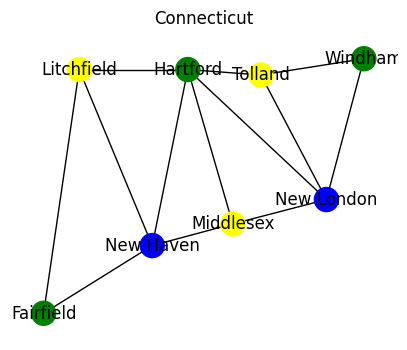

In [9]:
if connecticut_solution:
    draw_map("Connecticut", connecticut_graph, (5,4), connecticut_solution)

### Problem 2. Color Connecticut with Three Colors

In [10]:
connecticut_solution = color_map(connecticut_graph, ["red", "blue", "green"], trace=True)

MRV selected: Fairfield
Trying green for Fairfield
MRV selected: Litchfield
Trying blue for Litchfield
MRV selected: New Haven
Trying red for New Haven
MRV selected: Hartford
Trying green for Hartford
MRV selected: Middlesex
Trying blue for Middlesex
MRV selected: New London
Trying red for New London
MRV selected: Tolland
Trying blue for Tolland
MRV selected: Windham
Trying green for Windham


In [11]:
if connecticut_solution:
    test_coloring(connecticut_graph, connecticut_solution)

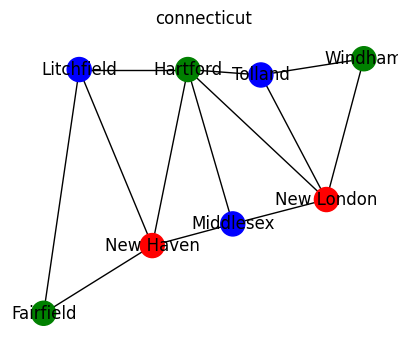

In [12]:
if connecticut_solution:
    draw_map("connecticut", connecticut_graph, (5,4), connecticut_solution)

### Problem 3. Color Europe with Four Colors

In [13]:
europe_graph = {
    "nodes":  ["Iceland", "Ireland", "United Kingdom", "Portugal", "Spain",
                 "France", "Belgium", "Netherlands", "Luxembourg", "Germany",
                 "Denmark", "Norway", "Sweden", "Finland", "Estonia",
                 "Latvia", "Lithuania", "Poland", "Czech Republic", "Austria",
                 "Liechtenstein", "Switzerland", "Italy", "Malta", "Greece",
                 "Albania", "Macedonia", "Kosovo", "Montenegro", "Bosnia Herzegovina",
                 "Serbia", "Croatia", "Slovenia", "Hungary", "Slovakia",
                 "Belarus", "Ukraine", "Moldova", "Romania", "Bulgaria",
                 "Cyprus", "Turkey", "Georgia", "Armenia", "Azerbaijan",
                 "Russia" ], 
    "edges": [(0,1), (0,2), (1,2), (2,5), (2,6), (2,7), (2,11), (3,4),
                 (4,5), (4,22), (5,6), (5,8), (5,9), (5,21), (5,22),(6,7),
                 (6,8), (6,9), (7,9), (8,9), (9,10), (9,12), (9,17), (9,18),
                 (9,19), (9,21), (10,11), (10,12), (10,17), (11,12), (11,13), (11,45), 
                 (12,13), (12,14), (12,15), (12,17), (13,14), (13,45), (14,15),
                 (14,45), (15,16), (15,35), (15,45), (16,17), (16,35), (17,18),
                 (17,34), (17,35), (17,36), (18,19), (18,34), (19,20), (19,21), 
                 (19,22), (19,32), (19,33), (19,34), (20,21), (21,22), (22,23),
                 (22,24), (22,25), (22,28), (22,29), (22,31), (22,32), (24,25),
                 (24,26), (24,39), (24,40), (24,41), (25,26), (25,27), (25,28),
                 (26,27), (26,30), (26,39), (27,28), (27,30), (28,29), (28,30),
                 (29,30), (29,31), (30,31), (30,33), (30,38), (30,39), (31,32),
                 (31,33), (32,33), (33,34), (33,36), (33,38), (34,36), (35,36),
                 (35,45), (36,37), (36,38), (36,45), (37,38), (38,39), (39,41),
                 (40,41), (41,42), (41,43), (41,44), (42,43), (42,44), (42,45),
                 (43,44), (44,45)],
    "coordinates": [( 18,147), ( 48, 83), ( 64, 90), ( 47, 28), ( 63, 34),
                   ( 78, 55), ( 82, 74), ( 84, 80), ( 82, 69), (100, 78),
                   ( 94, 97), (110,162), (116,144), (143,149), (140,111),
                   (137,102), (136, 95), (122, 78), (110, 67), (112, 60),
                   ( 98, 59), ( 93, 55), (102, 35), (108, 14), (130, 22),
                   (125, 32), (128, 37), (127, 40), (122, 42), (118, 47),
                   (127, 48), (116, 53), (111, 54), (122, 57), (124, 65),
                   (146, 87), (158, 65), (148, 57), (138, 54), (137, 41),
                   (160, 13), (168, 29), (189, 39), (194, 32), (202, 33),
                   (191,118)]}
print(europe_graph)

{'nodes': ['Iceland', 'Ireland', 'United Kingdom', 'Portugal', 'Spain', 'France', 'Belgium', 'Netherlands', 'Luxembourg', 'Germany', 'Denmark', 'Norway', 'Sweden', 'Finland', 'Estonia', 'Latvia', 'Lithuania', 'Poland', 'Czech Republic', 'Austria', 'Liechtenstein', 'Switzerland', 'Italy', 'Malta', 'Greece', 'Albania', 'Macedonia', 'Kosovo', 'Montenegro', 'Bosnia Herzegovina', 'Serbia', 'Croatia', 'Slovenia', 'Hungary', 'Slovakia', 'Belarus', 'Ukraine', 'Moldova', 'Romania', 'Bulgaria', 'Cyprus', 'Turkey', 'Georgia', 'Armenia', 'Azerbaijan', 'Russia'], 'edges': [(0, 1), (0, 2), (1, 2), (2, 5), (2, 6), (2, 7), (2, 11), (3, 4), (4, 5), (4, 22), (5, 6), (5, 8), (5, 9), (5, 21), (5, 22), (6, 7), (6, 8), (6, 9), (7, 9), (8, 9), (9, 10), (9, 12), (9, 17), (9, 18), (9, 19), (9, 21), (10, 11), (10, 12), (10, 17), (11, 12), (11, 13), (11, 45), (12, 13), (12, 14), (12, 15), (12, 17), (13, 14), (13, 45), (14, 15), (14, 45), (15, 16), (15, 35), (15, 45), (16, 17), (16, 35), (17, 18), (17, 34), (17, 

In [14]:
europe_solution = color_map(europe_graph, ["red", "blue", "green", "yellow"], trace=False)

In [15]:
if europe_solution:
    test_coloring(europe_graph, europe_solution)

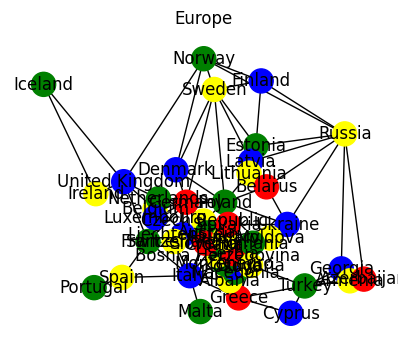

In [16]:
if europe_solution:
    draw_map("Europe", europe_graph, (5,4), europe_solution)

### Problem 4. Color Europe with Three Colors

In [17]:
europe_solution = color_map(europe_graph, ["red", "blue", "green"], trace=False)

In [18]:
if europe_solution:
    test_coloring(europe_graph, europe_solution)

In [19]:
if europe_solution:
    draw_map("Europe", europe_graph, (5,4), europe_solution)

## Part 2: Genetic Algorithms
Genetic algorithms can approximate the same constraint satisfaction solutions that we programmed algorithmically. We have provided some code to help you get started.

Color Europe from using four colors: ["red", "blue", "green", "yellow"]. 

Your implementation should:

* Start with a random population of candidates
* Run for a defined number of generations
* Select parents (implement tournament)
* Apply Crossover
* Apply Mutation
* Apply Culling (remove a fraction of the lowest fitness individuals from the new population)

You'll need encoders/decoders to switch between genomes and phenomes. 

You'll need an approproate fitness function. 

You'll need a suite of tunable parameters (number of generations, crossover rate, location, mutation rate, location, value, culling rate, and so on).

Every ten generations, print out the generation number, the fitness, genotype, and phenotype of the best individual in the population for the specific generation. Return the best individual of the entire run (in the same format).

Feel free to port over helper functions from your solution from Part #1

In [20]:
def initialize_population(pop_size, num_nodes, num_colors):
    """
    Creates the initial population of random individuals.
    """
    population = []

    # Adds a random individual where each individual is a list of color indices
    for i in range(pop_size):
        individual = [random.randint(0, num_colors-1) for i in range(num_nodes)]
        population.append(individual)

    return population

In [21]:
def fitness(individual, neighbor_set):
    """
    Computes the fitness of an individual where fitness is number of edges whose nodes have different colors.
    """
    conflicts = 0

    for i in neighbor_set:
        for j in neighbor_set[i]:
            if individual[i] == individual[j]:
                conflicts += 1

    return -conflicts // 2

In [22]:
def tournament_selection(population, fitnesses, tournament_size):
    """
    Selects one parent using tournament selection.
    """
    candidates = random.sample(range(len(population)), tournament_size)

    # Finds the candidate with the best fitness
    best = candidates[0]
    for idx in candidates:
        if fitnesses[idx] > fitnesses[best]:
            best = idx

    return population[best]

In [23]:
def crossover(parent1, parent2, crossover_rate):
    """
    Performs single-point crossover between two parents.
    """
    if random.random() > crossover_rate:
        return parent1[:], parent2[:]

    point = random.randint(1, len(parent1)-1)

    # Creates two random children with the parents' combined genetics
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]

    return child1, child2

In [24]:
def mutate(individual, mutation_rate, num_colors):
    """
    Mutates an individual by randomly changing genes.
    """
    for i in range(len(individual)):
        if random.random() < mutation_rate:
            individual[i] = random.randint(0, num_colors-1)

In [25]:
def cull_population(population, fitnesses, culling_rate):
    """
    Removes the lowest-fitness individuals.
    """
    paired = list(zip(population, fitnesses))
    paired.sort(key=lambda x: x[1], reverse=True)

    # Finds and returns survivors
    survivors = int(len(population) * (1 - culling_rate))

    return [ind for ind, fit in paired[:survivors]]

In [26]:
def report_fitness(generation, best_fitness, best_individual, color_list):
    """
    Reports the fitness of the best individual in the current generation.

    * **generation** int: The current generation number.
    * **best_fitness** float: The fitness score of the best individual.
    * **best_individual** list: The genotype of the best individual, represented as a list of color indices.
    * **color_list** list: A list of available colors. Each color is represented as a string (e.g., "red", "blue").
    """
    print(f"Generation {generation}: Best Fitness {best_fitness}, "
            f"Genotype {best_individual}, "
            f"Phenotype {[color_list[gene] for gene in best_individual]}")

In [27]:
def genetic_algorithm(color_list, constraint_graph, hyperparameters, trace=False):
    """
    Executes a genetic algorithm to solve a graph coloring problem by evolving a population of individuals over multiple generations. Each individual represents a potential solution, where nodes of the graph are assigned colors. The goal is to minimize conflicts between neighboring nodes sharing the same color.

    * **color_list** list: A list of available colors. Each color is represented as a string (e.g., "red", "blue").
    * **constraint_graph** dict: A dictionary representing the constraint graph, including nodes and their neighbors (edges).
    * **hyperparameters** dict: A dictionary containing hyperparameters for the genetic algorithm.
    * **trace** bool: If True, prints detailed information about the evolution process.

    **returns** list: The best individual found after NUM_GENERATIONS generations, represented as a list of color indices corresponding to each node in the graph. Additionally, the algorithm prints the best fitness, genotype, and phenotype at various points during the execution.
    """
    nodes = constraint_graph["nodes"]
    edges = constraint_graph["edges"]

    neighbor_set = {i: set() for i in range(len(nodes))}

    for a, b in edges:
        neighbor_set[a].add(b)
        neighbor_set[b].add(a)

    population = initialize_population(hyperparameters["POPULATION_SIZE"], len(nodes), len(color_list))
    best_individual = None
    best_fitness = float('-inf')

    for generation in range(hyperparameters["NUM_GENERATIONS"]):
        # Evaluates fitness of the population
        fitness_scores = [fitness(ind, neighbor_set) for ind in population]
        gen_best_index = max(range(len(population)), key=lambda i: fitness_scores[i])
        gen_best = population[gen_best_index]
        gen_best_fitness = fitness_scores[gen_best_index]

        if gen_best_fitness > best_fitness:
            best_fitness = gen_best_fitness
            best_individual = gen_best[:]
        # Reports the best individual and fitness found so far
        if trace and generation % 10 == 0:
            report_fitness(generation, best_fitness, best_individual, color_list)

        # Creates new population through selection, crossover, mutation, and culling
        new_population = []

        while len(new_population) < hyperparameters["POPULATION_SIZE"]:
            p1 = tournament_selection(population, fitness_scores, hyperparameters["TOURNAMENT_SIZE"])
            p2 = tournament_selection(population, fitness_scores, hyperparameters["TOURNAMENT_SIZE"])
            c1, c2 = crossover(p1, p2, hyperparameters["CROSSOVER_RATE"])

            mutate(c1, hyperparameters["MUTATION_RATE"], len(color_list))
            mutate(c2, hyperparameters["MUTATION_RATE"], len(color_list))

            new_population.append(c1)
            new_population.append(c2)

        population = new_population

        fitnesses = [fitness(ind, neighbor_set) for ind in population]
        population = cull_population(population, fitnesses, hyperparameters["CULLING_RATE"])

    # Final report of the best solution found
    if trace:
        print("Final report:")
        report_fitness(hyperparameters["NUM_GENERATIONS"], best_fitness, best_individual, color_list)
    
    return best_individual, best_fitness


#### Hyperparameters:
- **NUM_GENERATIONS** int: The number of generations for the genetic algorithm to evolve through. The higher this number, the longer the algorithm runs.
- **POPULATION_SIZE** int: The size of the population at each generation. A larger population can explore the solution space more thoroughly but increases computational cost.
- **CROSSOVER_RATE** float: The probability that two selected parents will undergo crossover. A higher rate means more offspring will be produced by recombination.
- **MUTATION_RATE** float: The probability that a mutation will occur in a given individual. This introduces genetic diversity and helps avoid local optima.
- **CULLING_RATE** float: The proportion of the population that will be culled (removed) at the end of each generation. A higher culling rate means only the fittest individuals are retained.
- **TOURNAMENT_SIZE** int: The number of individuals selected for tournament selection. Larger values give stronger individuals a higher chance of being selected.

In [28]:
def color_map_genetic(constraint_graph, color_list, trace=False): # AUTOGRADER FUNCTION: DO NOT MODIFY
    """
    Executes a genetic algorithm to solve a graph coloring problem by evolving a population of individuals over multiple generations. Each individual represents a potential solution, where nodes of the graph are assigned colors. The goal is to minimize conflicts between neighboring nodes sharing the same color.

    * **constraint_graph** dict: A dictionary representing the constraint graph, including nodes and their neighbors (edges).
    * **color_list** list: A list of available colors. Each color is represented as a string (e.g., "red", "blue").
    * **hyperparameters** dict: A dictionary containing hyperparameters for the genetic algorithm.
    * **trace** bool: If True, prints detailed information about the evolution process.

    **returns** list: The best individual found after NUM_GENERATIONS generations, represented as a list of color indices corresponding to each node in the graph.
    """
    # TODO: Define the parameters for the genetic algorithm
    random.seed(42) # Set random seed for reproducibility
    num_generations: int   = 200
    population_size: int   = 100
    crossover_rate : float = 0.8
    mutation_rate  : float = 0.05
    culling_rate   : float = 0.3
    tournament_size: int   = 5

    hyperparameters = {
        "NUM_GENERATIONS": num_generations,
        "POPULATION_SIZE": population_size,
        "CROSSOVER_RATE": crossover_rate,
        "MUTATION_RATE": mutation_rate,
        "CULLING_RATE": culling_rate,
        "TOURNAMENT_SIZE": tournament_size
    }
    best_individual, best_fitness = genetic_algorithm(color_list, constraint_graph, hyperparameters, trace)
    if best_fitness == 0:
        return [(constraint_graph["nodes"][i], color_list[best_individual[i]]) for i in range(len(best_individual))]
    else:
        print("No valid solution found.")
        return None

### Problem 5. Color Connecticut with Four Colors

In [29]:
connecticut_solution = color_map_genetic(connecticut_graph, ["red", "blue", "green", "yellow"], trace=True)

Generation 0: Best Fitness -1, Genotype [3, 1, 3, 2, 0, 1, 3, 2], Phenotype ['yellow', 'blue', 'yellow', 'green', 'red', 'blue', 'yellow', 'green']
Generation 10: Best Fitness 0, Genotype [1, 0, 2, 3, 0, 0, 2, 3], Phenotype ['blue', 'red', 'green', 'yellow', 'red', 'red', 'green', 'yellow']
Generation 20: Best Fitness 0, Genotype [1, 0, 2, 3, 0, 0, 2, 3], Phenotype ['blue', 'red', 'green', 'yellow', 'red', 'red', 'green', 'yellow']
Generation 30: Best Fitness 0, Genotype [1, 0, 2, 3, 0, 0, 2, 3], Phenotype ['blue', 'red', 'green', 'yellow', 'red', 'red', 'green', 'yellow']
Generation 40: Best Fitness 0, Genotype [1, 0, 2, 3, 0, 0, 2, 3], Phenotype ['blue', 'red', 'green', 'yellow', 'red', 'red', 'green', 'yellow']
Generation 50: Best Fitness 0, Genotype [1, 0, 2, 3, 0, 0, 2, 3], Phenotype ['blue', 'red', 'green', 'yellow', 'red', 'red', 'green', 'yellow']
Generation 60: Best Fitness 0, Genotype [1, 0, 2, 3, 0, 0, 2, 3], Phenotype ['blue', 'red', 'green', 'yellow', 'red', 'red', 'green'

In [30]:
if connecticut_solution:
    test_coloring(connecticut_graph, connecticut_solution)

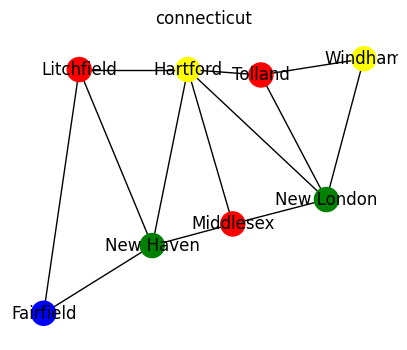

In [31]:
if connecticut_solution:
    draw_map("connecticut", connecticut_graph, (5,4), connecticut_solution)

### Problem 6. Color Connecticut with Three Colors

In [32]:
connecticut_solution = color_map(connecticut_graph, ["red", "blue", "green"], trace=True)

MRV selected: Fairfield
Trying green for Fairfield
MRV selected: Litchfield
Trying blue for Litchfield
MRV selected: New Haven
Trying red for New Haven
MRV selected: Hartford
Trying green for Hartford
MRV selected: Middlesex
Trying blue for Middlesex
MRV selected: New London
Trying red for New London
MRV selected: Tolland
Trying blue for Tolland
MRV selected: Windham
Trying green for Windham


In [33]:
if connecticut_solution:
    test_coloring(connecticut_graph, connecticut_solution)

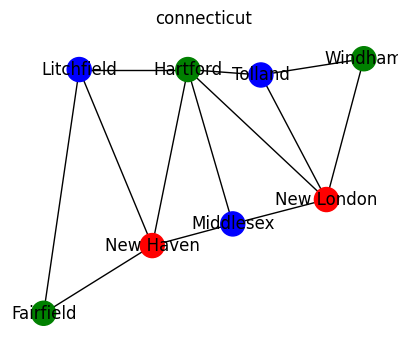

In [34]:
if connecticut_solution:
    draw_map("connecticut", connecticut_graph, (5,4), connecticut_solution)

### Problem 7. Color Europe with Four Colors

In [35]:
europe_solution = color_map_genetic(europe_graph, ["red", "blue", "green", "yellow"], trace=True)

Generation 0: Best Fitness -17, Genotype [0, 1, 3, 1, 0, 1, 3, 2, 0, 1, 3, 0, 0, 1, 3, 3, 0, 0, 2, 1, 2, 0, 0, 3, 3, 2, 0, 1, 3, 3, 0, 1, 2, 1, 0, 1, 1, 0, 2, 1, 0, 1, 0, 2, 3, 2], Phenotype ['red', 'blue', 'yellow', 'blue', 'red', 'blue', 'yellow', 'green', 'red', 'blue', 'yellow', 'red', 'red', 'blue', 'yellow', 'yellow', 'red', 'red', 'green', 'blue', 'green', 'red', 'red', 'yellow', 'yellow', 'green', 'red', 'blue', 'yellow', 'yellow', 'red', 'blue', 'green', 'blue', 'red', 'blue', 'blue', 'red', 'green', 'blue', 'red', 'blue', 'red', 'green', 'yellow', 'green']
Generation 10: Best Fitness -7, Genotype [2, 1, 3, 0, 1, 2, 0, 1, 0, 3, 2, 3, 0, 1, 1, 2, 0, 1, 2, 1, 3, 3, 0, 3, 3, 2, 1, 3, 1, 0, 2, 3, 1, 0, 3, 3, 2, 1, 3, 0, 0, 2, 3, 0, 1, 0], Phenotype ['green', 'blue', 'yellow', 'red', 'blue', 'green', 'red', 'blue', 'red', 'yellow', 'green', 'yellow', 'red', 'blue', 'blue', 'green', 'red', 'blue', 'green', 'blue', 'yellow', 'yellow', 'red', 'yellow', 'yellow', 'green', 'blue', 'yell

In [36]:
if europe_solution:
    test_coloring(europe_graph, europe_solution)

In [37]:
if europe_solution:
    draw_map("Europe", europe_graph, (10, 8), europe_solution)

### Problem 8. Color Europe with Four Colors

In [38]:
europe_solution = color_map_genetic(europe_graph, ["red", "blue", "green"], trace=True)

Generation 0: Best Fitness -24, Genotype [0, 1, 2, 2, 1, 1, 1, 1, 2, 2, 1, 0, 0, 2, 0, 1, 0, 2, 1, 1, 2, 0, 2, 2, 0, 1, 0, 0, 1, 1, 2, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0], Phenotype ['red', 'blue', 'green', 'green', 'blue', 'blue', 'blue', 'blue', 'green', 'green', 'blue', 'red', 'red', 'green', 'red', 'blue', 'red', 'green', 'blue', 'blue', 'green', 'red', 'green', 'green', 'red', 'blue', 'red', 'red', 'blue', 'blue', 'green', 'red', 'blue', 'red', 'red', 'blue', 'blue', 'red', 'blue', 'red', 'blue', 'green', 'blue', 'red', 'blue', 'red']
Generation 10: Best Fitness -13, Genotype [0, 2, 2, 1, 0, 1, 1, 0, 0, 2, 1, 1, 0, 2, 1, 2, 0, 2, 1, 1, 2, 0, 2, 0, 0, 1, 1, 0, 0, 1, 2, 0, 0, 2, 0, 1, 2, 0, 1, 0, 1, 2, 1, 0, 1, 0], Phenotype ['red', 'green', 'green', 'blue', 'red', 'blue', 'blue', 'red', 'red', 'green', 'blue', 'blue', 'red', 'green', 'blue', 'green', 'red', 'green', 'blue', 'blue', 'green', 'red', 'green', 'red', 'red', 'blue', 'blue', 'red', 'red', 'blue', 'green', 'red',

In [39]:
if europe_solution:
    test_coloring(europe_graph, europe_solution)

In [40]:
if europe_solution:
    draw_map("Europe", europe_graph, (10, 8), europe_solution)

## Before You Submit...

00. Re-read the general instructions provided above, and
01. Hit "Kernel"->"Restart & Run All". The first cell that is run should show [1], the second should show [2], and so on...
02. Submit your notebook (as .ipynb, not PDF) using Gradescope, and
03.  Do not submit any other files.